## Model Comparison — ResNet50 vs MobileNetV2
We compare two pretrained architectures on the same dataset.

We train 8 models per acrhitetcure, running randomized hyperparameter configuration serach to isolate the effect of architecture choice

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import functools
import keras
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess_input
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess_input
from tensorflow.keras import layers, models
import time
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os

For reproducibility

In [23]:
tf.random.set_seed(42)
np.random.seed(42)

In [24]:
def load_data(train_path, test_path, image_size):

  #Dataframe for train and test dataset
  df_train = pd.read_csv(train_path);
  df_test = pd.read_csv(test_path);

  #get pixel columns / features columns
  pixel_columns = df_train.columns[1:];

  #training set
  xtrain = df_train[pixel_columns].values;
  ytrain = df_train['label'].values;

  #test set
  xtest = df_test[pixel_columns].values;
  ytest = df_test['label'].values;


  #reshape flattened pixels into images
  #original image 28X28 grayscale
  xtrain = xtrain.reshape(-1, image_size, image_size, 1).astype('float32')
  xtest = xtest.reshape(-1, image_size, image_size, 1).astype('float32')

  #split training into training and validation
  xtrain, xval, ytrain, yval = train_test_split(xtrain, ytrain, test_size=0.2, random_state=42)

  return xtrain, xval, xtest, ytrain, yval, ytest

In [25]:
#change the path address accodrding to your Google Drive
train_path = '/content/drive/MyDrive/final-project/sign_mnist_train.csv'
test_path = '/content/drive/MyDrive/final-project/sign_mnist_test.csv'

image_size = 28;

xtrain, xval, xtest, ytrain, yval, ytest = load_data(train_path, test_path, image_size)



Helper function for checking if image suploded and shaped correctly

In [26]:
def draw(image):
    plt.imshow(image, cmap='gray')
    plt.title('Letter')
    plt.axis('off')
    plt.show()


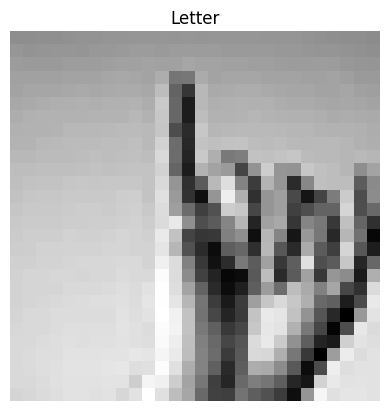


8

Training set size: 21964
Validation set size: 5491
Test set size: 7172


In [43]:
draw(xval[1]) #display image

print()
print(yval[1]) #display label
print("\nTraining set size:", xtrain.shape[0]) #display size of training set
print("Validation set size:", xval.shape[0]) #display size of valdiation set
print("Test set size:", xtest.shape[0]) #display size of test set

common base function to build model on top pretrained models

In [46]:
def build_model(base_model, num_classes, dense_units, drop_out_rate):

  #freeze base for feature extraction
  base_model.trainable = False

  #build model
  #Sequential model is a stack of layers where each layer has one input and output tensor
  model = models.Sequential([
      base_model,
      layers.GlobalAveragePooling2D(),
      layers.Dense(dense_units, activation='relu'),
      layers.Dropout(drop_out_rate),
      layers.Dense(num_classes, activation='softmax')
  ])

  return model

In [44]:
def build_resnet50_model(input_shape, num_classes, dense_unit = 128, drop_out_rate = .3):
  base = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
  return build_model(base, num_classes, dense_unit, drop_out_rate)


In [45]:
def build_mobilenetv2_model(input_shape, num_classes, dense_unit = 128, drop_out_rate = .3):
  base = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
  return build_model(base, num_classes, dense_unit, drop_out_rate)


Resize and convert to rgb and run through model's preprocessor

In [27]:
# Helper function to preprocess images on the fly
def preprocess_image_fn(image, label, target_size, preprocess_fn):
  image = tf.image.resize(image, target_size)
  image = tf.image.grayscale_to_rgb(image)
  # image = tf.cast(image, tf.float32) / 255.0 # Normalize pixel values
  image = preprocess_fn(image)
  return image, label

Efficiently resizes and converts to rgb images for training

In [19]:
def create_tf_dataset(images,labels, batch_size, target_size, preprocess_fn, shuffle=True):
  #converts Numpy arrays into TensorFlow Dataset object
  dataset = tf.data.Dataset.from_tensor_slices((images, labels))

  #randomizes order of dataset samples to prevent learning from data order
  if shuffle:
    dataset = dataset.shuffle(10000)

  #applies preprocess_image_fn to each image,label in dataset
  # Use functools.partial to pass target_size and model specific preprocess_fn to the external preprocess_image_fn
  dataset = dataset.map(functools.partial(preprocess_image_fn, target_size=target_size, preprocess_fn=preprocess_fn), num_parallel_calls=tf.data.AUTOTUNE)

  #combines samples into batches, prefetch prepares next batch while current one is processing
  dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
  return dataset

In [28]:
import random
import json

def sample_params(dense_options, dropout_options, lr_options):
    return {
        "dense": random.choice(dense_options),
        "dropout": random.choice(dropout_options),
        "lr": random.choice(lr_options)
    }


In [50]:
def train_and_evaluate_model(model_path, model_name, model_builder, preprocess_fn,xtrain, xval, ytrain, yval, xtest, ytest, epochs =10, batch_size=24):


  #variables for keeping track
  best_accuracy = 0
  best_config = None

  #options for params
  dense_options = [64, 128, 256]
  dropout_options = [.2, .3, .4]
  lr_options = [0.0001, .001]

  #Stops training early when a monitored metric stops improving
  #monitor: specified which metric to watch during training
  #patience: epochs to wait for an improvement
  #restore_best_weights: reverts model weight to best epoch
  early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

  checkpoint = ModelCheckpoint(
      model_path,
      monitor="val_accuracy",
      save_best_only=True,
      save_weights_only = False,
      mode="max"
  )

  #create datasets
  target_size = input_shape[0:2] # (128, 128)
  train_dataset = create_tf_dataset(xtrain, ytrain, batch_size, target_size, preprocess_fn)
  val_dataset = create_tf_dataset(xval, yval, batch_size, target_size, preprocess_fn, shuffle=False)

  #train models of combination of paramaters
  for i in range(8):

    #get random parameters
    params = sample_params(dense_options, dropout_options, lr_options)
    dense = params["dense"]
    dropout = params["dropout"]
    lr = params["lr"]

    print(f"\nTraining {model_name} with dense= {dense}, droput= {dropout}, lr= {lr}")

    #build mode
    model = model_builder(input_shape, num_classes, dense, dropout)

    #configue model for training
    #optimizer: optimizer algorithm used to update model weights, pass current learning rate
    #loss: how to compute error, sparse_categorial_crossentropy used for multi-class classification with integer labels,
    #metrics: what to report during training and evaluation
    model.compile(optimizer=optimizers.Adam(learning_rate=lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])


    #train compiled model using input data over epochs
    #returns loss and accuracy for each epoch
    history = model.fit(train_dataset, validation_data=val_dataset, epochs=epochs, callbacks=[early_stop, checkpoint])

    #save hsitory in dictionary
    experiment = {
      "config": {
          "batch_size": batch_size,
          "epochs": epochs,
          "learning_rate": lr,
          "dense_units": dense,
          "dropout": dropout
      },
      "history": history.history
      }

    all_experiments[model_name][f"run_{i}"] = experiment

    # Save after each run
    with open("/content/drive/MyDrive/final-project/experiments.json", "w") as f:
        json.dump(all_experiments, f)

    #get max accuracy of training on these parameters
    val_accuracy= max(history.history['val_accuracy'])
    print(f"Validation accuracy: {val_accuracy:.4f}")

    #save if model has better accuracy
    if val_accuracy > best_accuracy:
      best_accuracy = val_accuracy
      best_config = (dense, dropout, lr)



  return {
      'model_name': model_name,
      'best_config': best_config,
      'best_accuracy': best_accuracy,
  }

Training function, optimizing on dense_units, droput_out_rates, and learning_rates

Evaluate models on test data

In [41]:
def evaluate_model(model_name, model_path, test_dataset):

  #load best model
  best_model = tf.keras.models.load_model(model_path)

  #evaluate best model on test data
  test_loss, test_acc, = best_model.evaluate(test_dataset)

  print(f"\nModel: {model_name}\nTest accuracy: {test_acc:.4f}")

  return {
        "model_name": model_name,
        "test_accuracy": test_acc
    }




Inference time testing

In [34]:
def inference_testing(model_path, test_dataset):

  #load best model
  model = tf.keras.models.load_model(model_path)

  #create sample to test inference time
  sample = next(iter(test_dataset.take(1)))[0:1]

  runs = 10
   # warm-up
  model.predict(sample)

  times = []
  for _ in range(runs):
      start = time.time()
      model.predict(sample)
      end = time.time()
      times.append(end - start)

  return sum(times) / len(times)





Variables for saving model and training results

In [12]:
resnet_model_path = "/content/drive/MyDrive/final-project/resnet_best.keras"
mobilenet_model_path = "/content/drive/MyDrive/final-project/mobilenet_best.keras"

all_experiments  = {
    "ResNet50": {},
    "MobileNetV2": {}
}

In [15]:
#shape and classes that pretrained models expect
input_shape = (128, 128, 3);
num_classes= 26 # A - Z (0-25)


In [51]:

resnet50_result = train_and_evaluate_model(resnet_model_path,"ResNet50", build_resnet50_model, resnet_preprocess_input, xtrain, xval, ytrain, yval, xtest, ytest, epochs=10, batch_size = 24)
mobileNetv2_result = train_and_evaluate_model(mobilenet_model_path,"MobileNetV2", build_mobilenetv2_model, mobilenet_preprocess_input, xtrain, xval, ytrain, yval, xtest, ytest, epochs=10, batch_size = 24)


Training ResNet50 with dense= 64, droput= 0.2, lr= 0.0001
Epoch 1/10
916/916 ━━━━━━━━━━━━━━━━━━━━ 55s 48ms/step - accuracy: 0.6701 - loss: 1.1829 - val_accuracy: 0.9559 - val_loss: 0.2723
Epoch 2/10
916/916 ━━━━━━━━━━━━━━━━━━━━ 67s 36ms/step - accuracy: 0.9394 - loss: 0.2619 - val_accuracy: 0.9913 - val_loss: 0.0944
Epoch 3/10
916/916 ━━━━━━━━━━━━━━━━━━━━ 33s 36ms/step - accuracy: 0.9766 - loss: 0.1280 - val_accuracy: 0.9969 - val_loss: 0.0465
Epoch 4/10
916/916 ━━━━━━━━━━━━━━━━━━━━ 41s 36ms/step - accuracy: 0.9888 - loss: 0.0732 - val_accuracy: 0.9984 - val_loss: 0.0261
Epoch 5/10
916/916 ━━━━━━━━━━━━━━━━━━━━ 33s 36ms/step - accuracy: 0.9940 - loss: 0.0461 - val_accuracy: 0.9985 - val_loss: 0.0163
Epoch 6/10
916/916 ━━━━━━━━━━━━━━━━━━━━ 34s 37ms/step - accuracy: 0.9954 - loss: 0.0323 - val_accuracy: 0.9989 - val_loss: 0.0120
Epoch 7/10
916/916 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - accuracy: 0.9977 - loss: 0.0233 - val_accuracy: 0.9991 - val_loss: 0.0077
Epoch 8/10
916/916 ━━━━━━━━━━━━

Evaluate models in test data

In [54]:
#init shared variables
target_size = input_shape[0:2] # (128, 128)
batch_size = 24

#generate test dataset
resnet_test_dataset = create_tf_dataset(xtest, ytest, batch_size, target_size, resnet_preprocess_input, shuffle=False)
mobilenet_test_dataset = create_tf_dataset(xtest, ytest, batch_size, target_size, mobilenet_preprocess_input, shuffle=False)

resnet_result = evaluate_model("ResNet50", resnet_model_path, resnet_test_dataset)
mobilenet_result = evaluate_model("MobileNetV2", mobilenet_model_path, mobilenet_test_dataset)

results = [resnet_result, mobilenet_result]

299/299 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.9897 - loss: 0.0380

Model: ResNet50
Test accuracy: 0.9897
299/299 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.9915 - loss: 0.0499

Model: MobileNetV2
Test accuracy: 0.9915


In [37]:
print(f"\n Resnet50 Inference time: {inference_testing(resnet_model_path, resnet_test_dataset):.4f} seconds\n\n")
print(f"\n MobileNetV2 Inference time: { inference_testing(mobilenet_model_path, mobilenet_test_dataset):.4f} seconds")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step

 Resnet50 Inference time: 0.1187 seconds


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

 MobileNetV2 Inference time: 0.0893 seconds


### Inspecting `resnet_best.keras`

In [9]:
resnet_model_path = '/content/drive/MyDrive/final-project/resnet_best.keras'

# Load the model
loaded_resnet_model = tf.keras.models.load_model(resnet_model_path)

# Display the model summary
loaded_resnet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,986,192 (91.50 MB)

 Trainable params: 132,826 (518.85 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 265,654 (1.01 MB)

### Inspecting `mobilenet_best.keras`

In [7]:
mobilenet_model_path = '/content/drive/MyDrive/final-project/mobilenet_best.keras'

# Load the model
loaded_mobilenet_model = tf.keras.models.load_model(mobilenet_model_path)

# Display the model summary
loaded_mobilenet_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,759,952 (10.53 MB)

 Trainable params: 167,322 (653.60 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 334,646 (1.28 MB)